In [1]:
import pandas as pd
data = pd.read_csv("p2c-attempts-v1.csv")
data2 = data.replace('A01', 1).replace('A02', 2).replace('A03', 3)
print(data2.dtypes)

student            int64
assignment         int64
attempt            int64
grade              int64
submission time    int64
dtype: object


In [5]:
#data3 = data2.sort_values("student")
data3 = data2.sort_values(['student', 'assignment', "attempt"])
data3

,student,assignment,attempt,grade,submission time
1082,10133,1,1,85,35
1442,10133,1,2,81,32
385,10133,1,3,81,34
627,10133,1,4,97,35
1923,10133,1,5,88,7
...,...,...,...,...,...
342,99140,2,1,85,-97
638,99140,2,2,72,-99
1591,99140,2,3,98,-99
633,99858,1,1,76,-39


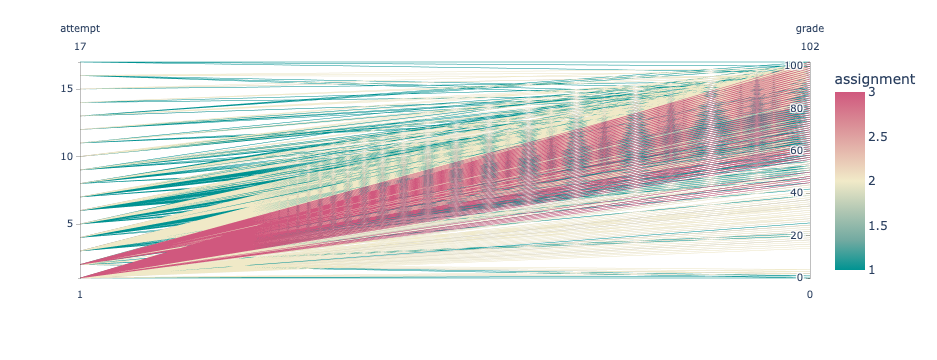

In [9]:
import plotly.express as px
fig = px.parallel_coordinates(data3, color="assignment",
                              dimensions=['attempt', 'grade'],
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              color_continuous_midpoint=2)
fig.show()

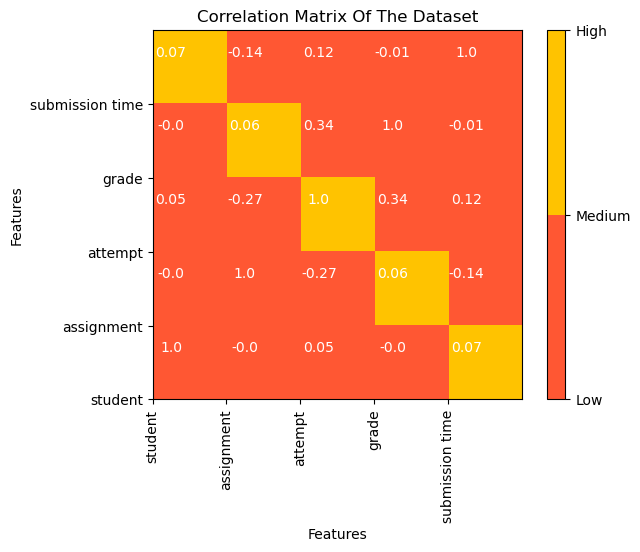

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
  
# Calculate correlation between columns
corr_matrix = data3.corr()
 
# Create a custom color
# map with blue and green colors
colors_list = ['#FF5733', '#FFC300']
cmap = colors.ListedColormap(colors_list)
 
# Plot the heatmap with custom colors and annotations
plt.imshow(corr_matrix, cmap=cmap, vmin=0\
           , vmax=1, extent=[0, 5, 0, 5])
for i in range(5):
    for j in range(5):
        plt.annotate(str(round(corr_matrix.values[i][j], 2)),\
                     xy=(j+0.25, i+0.7),
                     ha='center', va='center', color='white')

# Add colorbar
cbar = plt.colorbar(ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels(['Low', 'Medium', 'High'])
 
# Set plot title and axis labels
plt.title("Correlation Matrix Of The Dataset")
plt.xlabel("Features")
plt.ylabel("Features")
 
# Set tick labels
plt.xticks(range(len(corr_matrix.columns)),\
           corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)),
           corr_matrix.columns)
 
# Display the plot
plt.show()

Links used:
- https://plotly.com/python/parallel-coordinates-plot/
- https://www.geeksforgeeks.org/how-to-draw-2d-heatmap-using-matplotlib-in-python/